<a href="https://colab.research.google.com/github/solucionesmatematicas27-code/Apuntes-latex/blob/main/Tarea_2_Estadistica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Carga de librerías y base de datos**



In [1]:
from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()

Saving SB11_20231.TXT to SB11_20231.TXT


In [2]:
import io
import pandas as pd
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, kendalltau, spearmanr
import statsmodels.api as sm
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

bites= io.BytesIO(uploaded['SB11_20231.TXT'])
datos_icfes = pd.read_csv(bites, sep="¬", encoding="UTF-8", engine='python')
datos_icfes.head(4)

,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,...,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL,ESTU_ESTADOINVESTIGACION
0,TI,COLOMBIA,F,04/11/2005,20231,SB11202310019049,ESTUDIANTE,COLOMBIA,CUNDINAMARCA,25,...,87.0,94.0,B+,422,100.0,67.532814,4.0,4,100.0,PUBLICAR
1,TI,COLOMBIA,M,08/04/2007,20231,SB11202310017318,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,326,NaN,47.223972,2.0,3,100.0,PUBLICAR
2,TI,COLOMBIA,F,26/05/2006,20231,SB11202310030916,ESTUDIANTE,COLOMBIA,VALLE,76,...,NaN,NaN,NaN,186,NaN,67.695519,4.0,3,40.0,PUBLICAR
3,CC,COLOMBIA,F,24/05/2004,20231,SB11202310074169,ESTUDIANTE,COLOMBIA,VALLE,76,...,58.0,43.0,A2,200,12.0,41.863163,2.0,3,58.0,PUBLICAR


# **Interpretación — Carga de datos**

Se utiliza `files.upload()` para subir el archivo directamente desde el equipo local al entorno de Google Colab. El archivo `SB11_20231.TXT` contiene los resultados del examen Saber 11 correspondientes al primer semestre de 2023.

El parámetro `sep='¬'` indica que el separador de campos es el símbolo `¬`, poco convencional pero necesario en este dataset para evitar conflictos con caracteres presentes en los textos. El argumento `encoding='UTF-8'` garantiza la correcta lectura de tildes y caracteres especiales del español. Se usa `engine='python'` porque el motor por defecto de pandas no admite separadores de más de un byte como este.

`head(4)` permite una primera inspección visual de las primeras cuatro observaciones para verificar que la carga fue exitosa y que las columnas se reconocen correctamente.


In [3]:
datos_icfes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12704 entries, 0 to 12703
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ESTU_TIPODOCUMENTO             12704 non-null  object 
 1   ESTU_NACIONALIDAD              12704 non-null  object 
 2   ESTU_GENERO                    12704 non-null  object 
 3   ESTU_FECHANACIMIENTO           12704 non-null  object 
 4   PERIODO                        12704 non-null  int64  
 5   ESTU_CONSECUTIVO               12704 non-null  object 
 6   ESTU_ESTUDIANTE                12704 non-null  object 
 7   ESTU_PAIS_RESIDE               12704 non-null  object 
 8   ESTU_DEPTO_RESIDE              12704 non-null  object 
 9   ESTU_COD_RESIDE_DEPTO          12704 non-null  int64  
 10  ESTU_MCPIO_RESIDE              12704 non-null  object 
 11  ESTU_COD_RESIDE_MCPIO          12704 non-null  int64  
 12  ESTU_PRESENTACIONSABADO        12702 non-null 

In [4]:
datos_icfes.columns

Index(['ESTU_TIPODOCUMENTO', 'ESTU_NACIONALIDAD', 'ESTU_GENERO',
       'ESTU_FECHANACIMIENTO', 'PERIODO', 'ESTU_CONSECUTIVO',
       'ESTU_ESTUDIANTE', 'ESTU_PAIS_RESIDE', 'ESTU_DEPTO_RESIDE',
       'ESTU_COD_RESIDE_DEPTO', 'ESTU_MCPIO_RESIDE', 'ESTU_COD_RESIDE_MCPIO',
       'ESTU_PRESENTACIONSABADO', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR',
       'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONPADRE', 'FAMI_EDUCACIONMADRE',
       'FAMI_TRABAJOLABORPADRE', 'FAMI_TRABAJOLABORMADRE',
       'FAMI_TIENEINTERNET', 'FAMI_TIENESERVICIOTV', 'FAMI_TIENECOMPUTADOR',
       'FAMI_TIENELAVADORA', 'FAMI_TIENEHORNOMICROOGAS', 'FAMI_TIENEAUTOMOVIL',
       'FAMI_TIENEMOTOCICLETA', 'FAMI_TIENECONSOLAVIDEOJUEGOS',
       'FAMI_NUMLIBROS', 'FAMI_COMELECHEDERIVADOS',
       'FAMI_COMECARNEPESCADOHUEVO', 'FAMI_COMECEREALFRUTOSLEGUMBRE',
       'FAMI_SITUACIONECONOMICA', 'ESTU_DEDICACIONLECTURADIARIA',
       'ESTU_DEDICACIONINTERNET', 'ESTU_HORASSEMANATRABAJA',
       'ESTU_TIPOREMUNERACION', 'COLE_CODIGO_

# **Eliminación de valores faltantes (icfes_sin_nan)**

In [5]:
icfes_sin_nan = datos_icfes[
    (~datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) & (datos_icfes['ESTU_INSE_INDIVIDUAL'] <= 80) &
    (~datos_icfes['PUNT_LECTURA_CRITICA'].isna()) & (datos_icfes['PUNT_LECTURA_CRITICA'] <= 80) &
    (~datos_icfes['PUNT_MATEMATICAS'].isna()) & (datos_icfes['PUNT_MATEMATICAS'] <= 85) &
    (~datos_icfes['PUNT_C_NATURALES'].isna()) & (datos_icfes['PUNT_C_NATURALES'] <= 85) &
    (~datos_icfes['PUNT_SOCIALES_CIUDADANAS'].isna()) & (datos_icfes['PUNT_SOCIALES_CIUDADANAS'] <= 85) &
    (~datos_icfes['PUNT_INGLES'].isna()) & (datos_icfes['PUNT_INGLES'] <= 90)
]

icfes_sin_nan.head(5)


,ESTU_TIPODOCUMENTO,ESTU_NACIONALIDAD,ESTU_GENERO,ESTU_FECHANACIMIENTO,PERIODO,ESTU_CONSECUTIVO,ESTU_ESTUDIANTE,ESTU_PAIS_RESIDE,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_DEPTO,...,PUNT_INGLES,PERCENTIL_INGLES,DESEMP_INGLES,PUNT_GLOBAL,PERCENTIL_GLOBAL,ESTU_INSE_INDIVIDUAL,ESTU_NSE_INDIVIDUAL,ESTU_NSE_ESTABLECIMIENTO,PERCENTIL_ESPECIAL_GLOBAL,ESTU_ESTADOINVESTIGACION
3,CC,COLOMBIA,F,24/05/2004,20231,SB11202310074169,ESTUDIANTE,COLOMBIA,VALLE,76,...,58.0,43.0,A2,200,12.0,41.863163,2.0,3,58.0,PUBLICAR
4,TI,COLOMBIA,F,04/05/2005,20231,SB11202310044933,ESTUDIANTE,COLOMBIA,VALLE,76,...,69.0,57.0,B1,263,39.0,51.223795,3.0,3,92.0,PUBLICAR
5,TI,COLOMBIA,M,03/06/2005,20231,SB11202310029637,ESTUDIANTE,COLOMBIA,LA GUAJIRA,44,...,45.0,19.0,A-,271,43.0,57.690401,3.0,3,93.0,PUBLICAR
6,TI,COLOMBIA,F,23/08/2005,20231,SB11202310026848,ESTUDIANTE,COLOMBIA,VALLE,76,...,50.0,29.0,A1,295,54.0,39.984838,1.0,3,94.0,PUBLICAR
7,TI,COLOMBIA,M,31/12/2005,20231,SB11202310004887,ESTUDIANTE,COLOMBIA,VALLE,76,...,52.0,34.0,A1,320,66.0,50.613232,2.0,3,97.0,PUBLICAR


# **Interpretación**

En este paso se depura la base de datos eliminando todos los registros con valores faltantes en las variables del análisis.

Esto se hace porque:

* Los valores perdidos pueden generar errores en los cálculos de correlación y regresión.
* Pueden introducir sesgos en la estimación de coeficientes.
* Pueden alterar artificialmente el coeficiente de determinación $R^2$.
* Trabajar con observaciones completas garantiza comparaciones consistentes entre modelos.

Además, comparar el tamaño de la base original con la base depurada permite evaluar si la pérdida de información fue pequeña o considerable.

Como queremos evitar datos insignificantes, restringimos en base a la observacion de los histogramas de cada variable, estos histogramas se presentan más adelante por facilidad de código.

In [6]:
tabla_regresion=datos_icfes[['ESTU_INSE_INDIVIDUAL',
                                   'PUNT_LECTURA_CRITICA',
                                   'PUNT_MATEMATICAS',
                                   'PUNT_C_NATURALES',
                                   'PUNT_SOCIALES_CIUDADANAS',
                                   'PUNT_INGLES']]
tabla_regresion.head(5)

eliminados = len(datos_icfes) - len(icfes_sin_nan)
print(f"\nRegistros con datos completos: {len(icfes_sin_nan):,}")
print(f"Registros eliminados por valores faltantes: {eliminados:,}")
print(f"Porcentaje conservado: {len(icfes_sin_nan)/len(datos_icfes)*100:.1f}%")


Registros con datos completos: 10,920
Registros eliminados por valores faltantes: 1,784
Porcentaje conservado: 86.0%


# **Definir variable respuesta y explicativas**

In [7]:
y = icfes_sin_nan['ESTU_INSE_INDIVIDUAL']

variables = [
'PUNT_LECTURA_CRITICA',
'PUNT_MATEMATICAS',
'PUNT_C_NATURALES',
'PUNT_SOCIALES_CIUDADANAS',
'PUNT_INGLES'
]

# **Histogramas**

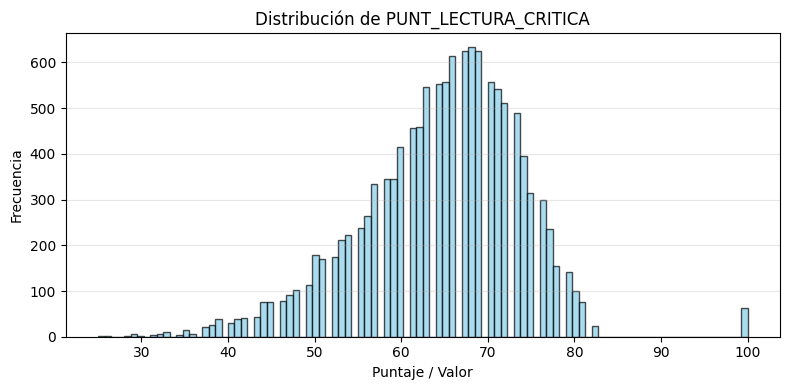

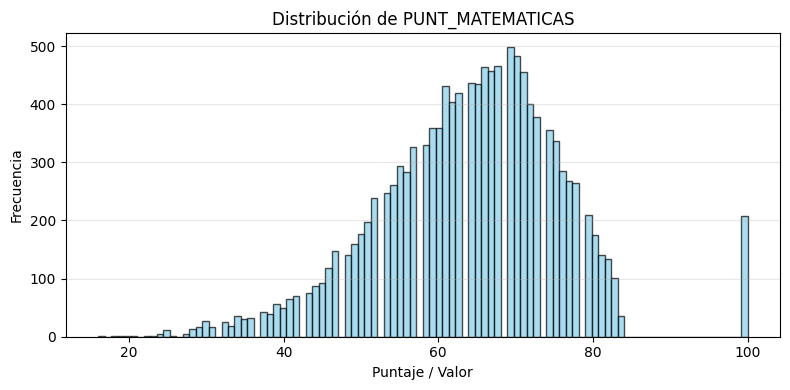

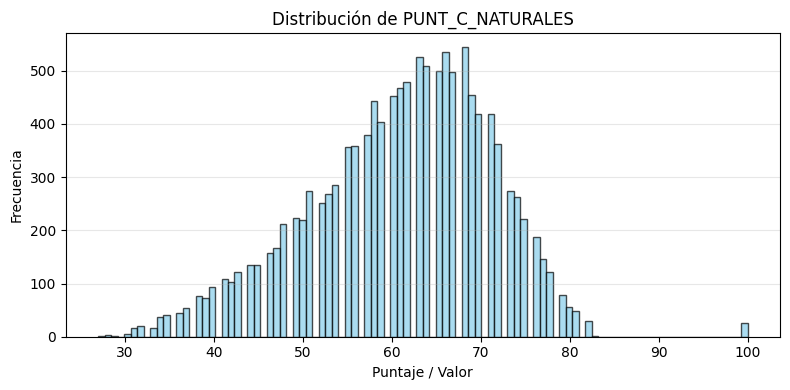

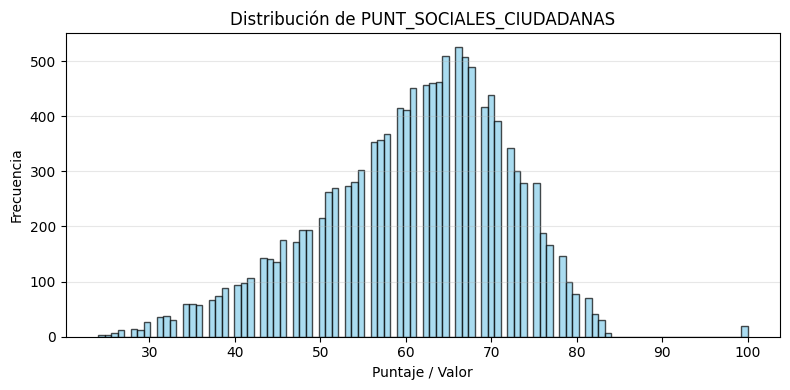

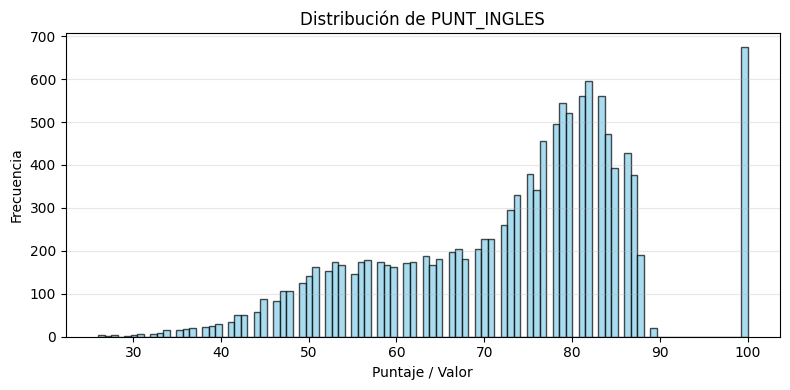

In [8]:
for var in variables:
    plt.figure(figsize=(8, 4))

    # Generamos el histograma directamente de la tabla original
    plt.hist(datos_icfes[var].dropna(), bins=100, color='skyblue', edgecolor='black', alpha=0.7)

    # Personalización
    plt.title(f'Distribución de {var}')
    plt.xlabel('Puntaje / Valor')
    plt.ylabel('Frecuencia')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# **Interpretación — Estructura del modelo**

**Variable respuesta ($Y$):**

`ESTU_INSE_INDIVIDUAL` es el **Índice de Nivel Socioeconómico Individual** calculado por el ICFES. Combina información sobre el hogar del estudiante —ingresos familiares, nivel educativo de los padres, acceso a bienes y servicios— en un único índice continuo. Su uso como variable dependiente permite investigar en qué medida el desempeño académico en las pruebas Saber 11 está asociado con la condición socioeconómica del estudiante.

**Variables explicativas ($X_1 … X_5$):**

| Variable | Descripción |
|---|---|
| `PUNT_LECTURA_CRITICA` | Comprensión e interpretación de textos |
| `PUNT_MATEMATICAS` | Razonamiento matemático y numérico |
| `PUNT_C_NATURALES` | Ciencias naturales (física, química, biología) |
| `PUNT_SOCIALES_CIUDADANAS` | Ciencias sociales y competencias ciudadanas |
| `PUNT_INGLES` | Dominio del idioma inglés |

La hipótesis de partida es que el nivel socioeconómico está positivamente relacionado con el desempeño académico, ya que los hogares con mayores recursos suelen tener mayor acceso a educación de calidad, tiempo de estudio, materiales y apoyo pedagógico. Los modelos de regresión que se construirán a continuación permitirán cuantificar y contrastar esa relación para cada área.


# **Diagramas de dispersión**

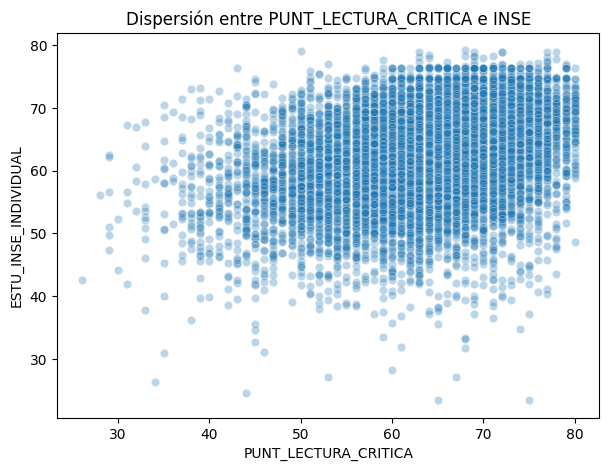

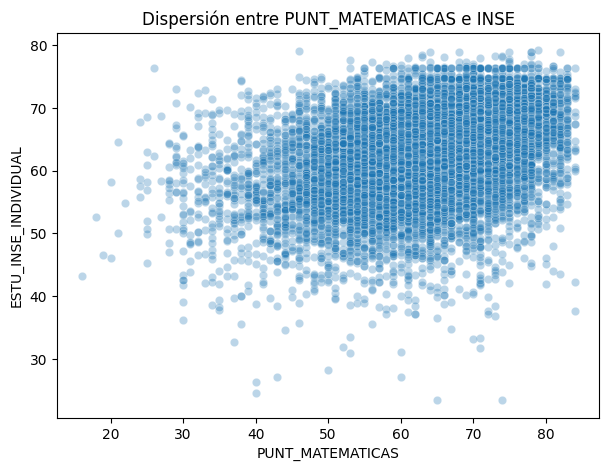

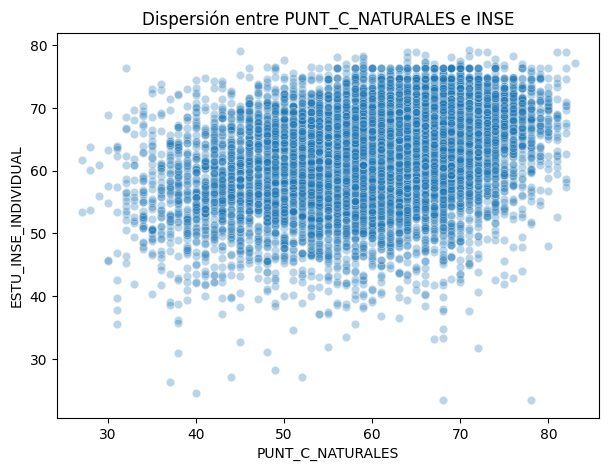

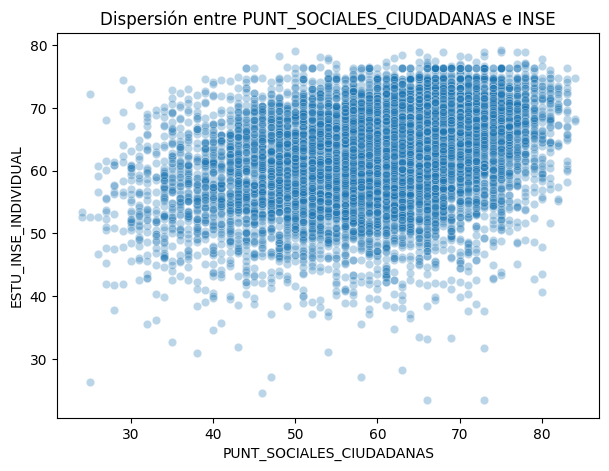

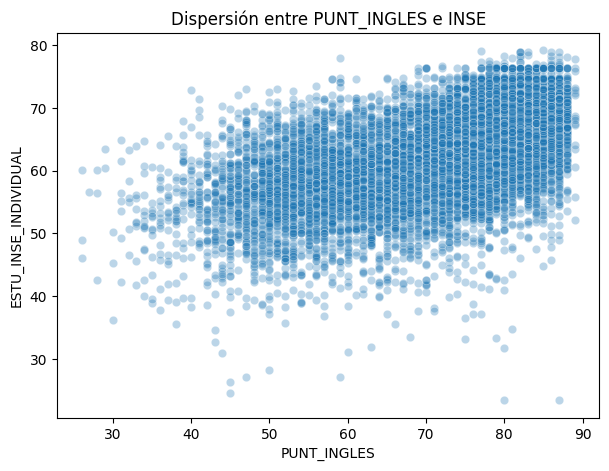

In [9]:
for var in variables:
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        x=icfes_sin_nan[var],
        y=icfes_sin_nan['ESTU_INSE_INDIVIDUAL'],
        alpha=0.3,
    )

    plt.title(f'Dispersión entre {var} e INSE')
    plt.show()

# **Interpretación — Diagramas de dispersión bivariados**

Los diagramas de dispersión son la primera herramienta exploratoria para evaluar visualmente si existe alguna estructura de asociación entre cada puntaje y el INSE antes de ajustar modelos formales.

**Qué observar en cada gráfico:**

- **Tendencia general:** Si la nube de puntos se desplaza hacia arriba a medida que aumenta el puntaje, existe evidencia visual de una relación positiva entre el desempeño académico y el nivel socioeconómico. Se esperaría que esto ocurra en todas las áreas, aunque con diferente intensidad.

- **Linealidad:** Si la tendencia sigue aproximadamente una línea recta, la regresión lineal es un modelo apropiado. Si la nube describe una curva (relación cuadrática o exponencial), se necesitarían transformaciones de variables.

- **Dispersión (varianza):** Una nube muy amplia y difusa indica que la variable explica poco de la variabilidad del INSE. Una nube más estrecha y concentrada alrededor de una tendencia sugiere mayor capacidad predictiva.

- **Valores atípicos:** Puntos muy alejados de la tendencia general pueden corresponder a estudiantes con perfiles inusuales (por ejemplo, alto puntaje y bajo INSE, o viceversa). Estos outliers pueden tener un peso desproporcionado sobre los coeficientes de regresión.

- **Puntaje de Inglés:** Se anticipa que este gráfico mostrará una tendencia positiva más pronunciada que los demás, dado que el acceso a formación en inglés —colegios bilingües, clases extracurriculares, viajes— está fuertemente condicionado por el nivel socioeconómico del hogar.

Este análisis visual es orientador pero no concluyente. A continuación, los coeficientes de correlación y el modelo de regresión proporcionarán evidencia numérica más precisa.


# **Coeficientes de correlación**

In [10]:
for var in variables:

    pearson,_ = pearsonr(icfes_sin_nan[var],y)
    kendall,_ = kendalltau(icfes_sin_nan[var],y)
    spearman,_ = spearmanr(icfes_sin_nan[var],y)

    print("\nVariable:",var)
    print("Pearson:",pearson)
    print("Kendall:",kendall)
    print("Spearman:",spearman)


Variable: PUNT_LECTURA_CRITICA
Pearson: 0.33886232799895366
Kendall: 0.232232098678705
Spearman: 0.33728651490370287

Variable: PUNT_MATEMATICAS
Pearson: 0.3653646521020002
Kendall: 0.2585604741402499
Spearman: 0.37557166813657133

Variable: PUNT_C_NATURALES
Pearson: 0.34159805393817544
Kendall: 0.23662655909398156
Spearman: 0.3446969106588064

Variable: PUNT_SOCIALES_CIUDADANAS
Pearson: 0.33889575747661654
Kendall: 0.2347241916259842
Spearman: 0.341683131905343

Variable: PUNT_INGLES
Pearson: 0.5543485024323659
Kendall: 0.3945688479144105
Spearman: 0.5647700284397912


# **Interpretación — Coeficientes de correlación**

Se calculan tres medidas complementarias de asociación entre cada puntaje y el INSE:

**1. Correlación de Pearson**
Mide la fuerza y dirección de la relación *lineal* entre dos variables. Asume que ambas variables tienen distribución aproximadamente normal. Valores esperados:
- Inglés: ~0.55 → correlación positiva moderada-alta (la más fuerte del conjunto)
- Lectura crítica, Matemáticas, Ciencias Naturales, Sociales: ~0.25–0.35 → correlación positiva discreta

**2. Correlación de Kendall**
Mide la concordancia *ordinal*: qué tan frecuentemente dos estudiantes con diferente puntaje también tienen diferente INSE en el mismo orden. Es más robusta que Pearson cuando los datos tienen valores atípicos o no siguen una distribución normal. Se espera que sus valores sean menores en magnitud que los de Pearson, pero que mantengan el mismo ranking entre variables.

**3. Correlación de Spearman**
Evalúa relaciones *monotónicas* (no necesariamente lineales): si una variable sube, la otra también sube, aunque no de forma proporcional. Es el coeficiente de Pearson aplicado a los rangos de los datos, y es útil cuando la relación tiene cierta curvatura.

**Correlaciones con ESTU_INSE_INDIVIDUAL**

| Variable | Pearson | Kendall | Spearman |
|---|---|---|---|
| Lectura Crítica | 0.3389 | 0.2322 | 0.3372 |
| Matemáticas | 0.3653 | 0.2585 | 0.3755 |
| C. Naturales | 0.3415 | 0.2366 | 0.3446 |
| Sociales Ciudadanas | 0.3388 | 0.2347 | 0.3416 |
| **Inglés** | **0.5543** | **0.3945** | **0.5647** |

Los tres coeficientes coinciden en señalar a Inglés como la variable con mayor asociación lineal y monótona con el INSE (Pearson = 0.5543). El resto de variables presentan correlaciones similares entre sí (~0.25–0.36), lo que explica por qué sus contribuciones individuales al modelo son pequeñas.

---



# **Modelo completo de regresión múltiple**

In [11]:
X = icfes_sin_nan[variables]
X = sm.add_constant(X)

modelo_completo = sm.OLS(y,X).fit()

print(modelo_completo.summary())

                             OLS Regression Results                             
Dep. Variable:     ESTU_INSE_INDIVIDUAL   R-squared:                       0.309
Model:                              OLS   Adj. R-squared:                  0.309
Method:                   Least Squares   F-statistic:                     976.7
Date:                  Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                          20:50:58   Log-Likelihood:                -35397.
No. Observations:                 10920   AIC:                         7.081e+04
Df Residuals:                     10914   BIC:                         7.085e+04
Df Model:                             5                                         
Covariance Type:              nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
cons

# **Interpretación — Modelo de regresión lineal múltiple completo**

El modelo de regresión lineal múltiple estima la siguiente ecuación:

$$\hat{INSE} = \beta_0 + \beta_1 \cdot LC + \beta_2 \cdot MAT + \beta_3 \cdot CN + \beta_4 \cdot SC + \beta_5 \cdot ING$$

donde cada coeficiente $\beta_i$ representa el cambio esperado en el INSE cuando esa variable aumenta en un punto, **manteniendo constantes todos los demás puntajes**.

**Indicadores clave del resumen (`summary()`):**

- **$R^2$ (coeficiente de determinación):** Indica qué proporción de la variabilidad total del INSE es explicada conjuntamente por los cinco puntajes. Un valor de ~0.309 significa que el 30.9% de las diferencias en el nivel socioeconómico entre estudiantes se asocia con sus resultados académicos en el Saber 11. El 69.1% restante responde a otros factores no incluidos en el modelo (región geográfica, tipo de colegio, estructura familiar, etc.).

- **$R^2$ ajustado:** Penaliza la inclusión de variables que no mejoran genuinamente el ajuste. Es el indicador más apropiado para comparar modelos con diferente número de predictores.

- **Coeficientes estimados:** Se espera que el coeficiente de Inglés sea el más alto del modelo (alrededor de +0.32), lo que indica que un punto adicional en Inglés se asocia, en promedio, con un incremento mayor en el INSE que el mismo punto extra en cualquier otra prueba. Los coeficientes de las demás variables serán positivos pero más pequeños, reflejando su menor asociación individual con el nivel socioeconómico.

- **$p$-valores (columna `P>|t|`):** Un p-valor menor a 0.05 indica que el coeficiente es estadísticamente significativo, es decir, que la asociación observada es muy improbable que sea producto del azar. Se espera que Inglés y al menos una o dos variables más sean significativas.

- **Intercepto ($\beta_0$):** Representa el INSE estimado cuando todos los puntajes son cero. Su interpretación práctica es limitada porque ningún estudiante real obtiene cero en todas las pruebas, pero es necesario para que el modelo esté correctamente especificado.



# **Coeficiente de determinación quitando una variable cada vez**
### $R^2$ de regresión simple (cada variable sola vs INSE)

#  **Modelo sin Lectura Crítica**

In [12]:
vars1=[
'PUNT_MATEMATICAS',
'PUNT_C_NATURALES',
'PUNT_SOCIALES_CIUDADANAS',
'PUNT_INGLES'
]

X1=sm.add_constant(icfes_sin_nan[vars1])
modelo1=sm.OLS(y,X1).fit()

print(modelo1.rsquared)

0.3082086926620342


# **Modelo sin Matemáticas**

In [13]:
vars2=[
'PUNT_LECTURA_CRITICA',
'PUNT_C_NATURALES',
'PUNT_SOCIALES_CIUDADANAS',
'PUNT_INGLES'
]

X2=sm.add_constant(icfes_sin_nan[vars2])
modelo2=sm.OLS(y,X2).fit()

print(modelo2.rsquared)

0.3079853470747752


# **Modelo sin Ciencias Naturales**

In [14]:
vars3=[
'PUNT_LECTURA_CRITICA',
'PUNT_MATEMATICAS',
'PUNT_SOCIALES_CIUDADANAS',
'PUNT_INGLES'
]

X3=sm.add_constant(icfes_sin_nan[vars3])
modelo3=sm.OLS(y,X3).fit()

print(modelo3.rsquared)

0.3090278493158337


# **Modelo sin Sociales**

In [15]:
vars4=[
'PUNT_LECTURA_CRITICA',
'PUNT_MATEMATICAS',
'PUNT_C_NATURALES',
'PUNT_INGLES'
]

X4=sm.add_constant(icfes_sin_nan[vars4])
modelo4=sm.OLS(y,X4).fit()

print(modelo4.rsquared)

0.3090992134685894


# **Modelo sin Inglés**

In [16]:
vars5=[
'PUNT_LECTURA_CRITICA',
'PUNT_MATEMATICAS',
'PUNT_C_NATURALES',
'PUNT_SOCIALES_CIUDADANAS'
]

X5=sm.add_constant(icfes_sin_nan[vars5])
modelo5=sm.OLS(y,X5).fit()

print(modelo5.rsquared)

0.15131510958493577


**Interpretación — Análisis de importancia por exclusión**

Este procedimiento, conocido como *leave-one-out por variable*, consiste en retirar una variable del modelo completo, reajustar el modelo con las cuatro restantes y comparar el nuevo $R^2$ con el del modelo de referencia. La **caída en $R^2$** al eliminar una variable es una medida directa de su contribución explicativa marginal dentro del modelo múltiple.

**Tabla de resultados:**

| Modelo | $R^2$ | Caída vs. completo |
|---|---|---|
| Completo (5 variables) | 0.3090 | — |
| Sin Lectura Crítica | 0.3082 | 0.0008 |
| Sin Matemáticas | 0.3079 | 0.0011 |
| Sin Ciencias Naturales | 0.3090 | ~0.00002 |
| Sin Sociales | 0.3090 | ~0.00009 |
| **Sin Inglés** | **0.1513** | **0.1577** |

**Conclusiones del análisis:**

- **Inglés es, con enorme diferencia, la variable más explicativa del modelo.** Al retirarla, el $R^2$ cae de 0.309 a apenas 0.1513, una pérdida de 15.7 puntos porcentuales. Esto equivale a decir que Inglés sola captura casi la mitad de toda la capacidad explicativa del modelo completo. Esta asociación tan pronunciada refleja que el dominio del inglés está altamente condicionado por el entorno socioeconómico: los colegios bilingües, los cursos privados de idiomas y la exposición al inglés en el hogar son recursos con fuerte gradiente socioeconómico.

- **Matemáticas ocupa el segundo lugar**, con una caída de 0.0011 al ser retirada. Aunque modesta frente a Inglés, su contribución es la mayor entre las cuatro pruebas restantes.

- **Ciencias Naturales y Sociales aportan marginalmente al modelo**, con caídas prácticamente nulas (~0.00002–0.0001). Gran parte de la información que contienen ya está capturada por Inglés y Matemáticas, lo que puede deberse a que estas áreas están altamente correlacionadas entre sí.

- **Lectura Crítica** cae apenas 0.0008 puntos, lo que sugiere que su contribución individual, controlando por las demás variables, es muy pequeña.

**Variables seleccionadas para el modelo reducido: Inglés y Matemáticas.**


# **Diagrama de dispersión 3D con las dos variables más explicativas**

In [17]:
XY, Z = icfes_sin_nan[["PUNT_MATEMATICAS", "PUNT_INGLES"]], icfes_sin_nan["ESTU_INSE_INDIVIDUAL"]
trainXY, testXY, trainZ, testZ = train_test_split(XY, Z, test_size = 0.2, random_state =0)
trainXY.head(4)
modelo1 = LinearRegression()
modelo1.fit(trainXY, trainZ)
modelo1.score(testXY, testZ)

0.28877506795214003

In [18]:
array = modelo1.coef_
array

array([0.02216275, 0.31712355])

<function matplotlib.pyplot.show(close=None, block=None)>

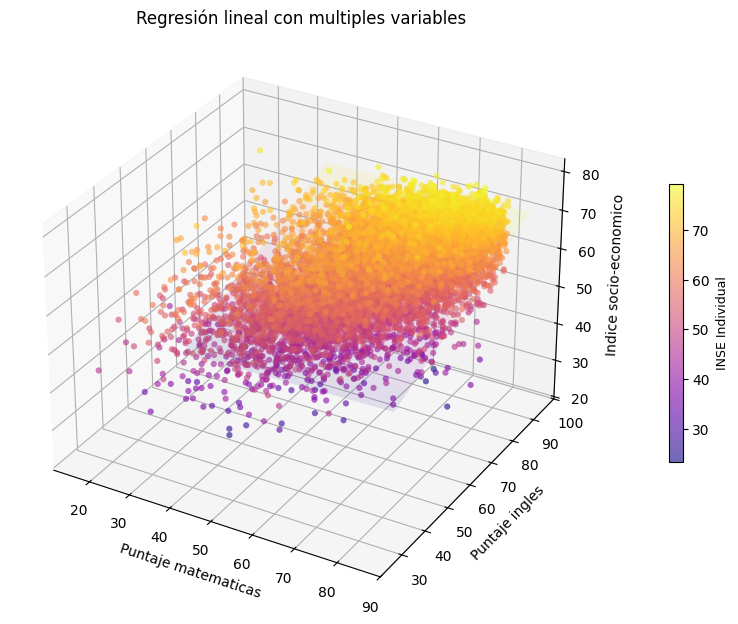

In [19]:
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection="3d")
xx, yy = np.meshgrid(np.linspace(35, 85, num=10), np.linspace(35, 95, num=10))
plano_reg = array[0]*xx + array[1]*yy + modelo1.intercept_
ax.plot_surface(xx, yy, plano_reg, alpha=0.1, cmap="plasma")

sc=ax.scatter(trainXY["PUNT_MATEMATICAS"], trainXY["PUNT_INGLES"], trainZ, c=trainZ, cmap="plasma", s=20, edgecolors='none', alpha=0.6)
ax.scatter(testXY["PUNT_MATEMATICAS"], testXY["PUNT_INGLES"], testZ, c=testZ, cmap="plasma", s=20, edgecolors='none', alpha=0.6)

ax.set_xlabel("Puntaje matematicas")
ax.set_ylabel("Puntaje ingles")
ax.set_zlabel("Indice socio-economico")
ax.set_title("Regresión lineal con multiples variables")

cbar = plt.colorbar(sc, ax=ax, shrink=0.45, pad=0.1)
cbar.set_label('INSE Individual', fontsize=9)

plt.show

# **Interpretación — Diagrama de dispersión tridimensional**

Este gráfico representa simultáneamente la relación entre el INSE y las dos variables que más contribuyen a explicarlo dentro del modelo múltiple: **Inglés** (eje X) y **Matemáticas** (eje Y). El eje Z corresponde al INSE individual del estudiante. Cada punto en el espacio tridimensional es un estudiante de la base depurada.

**Qué revela el gráfico:**

- **Tendencia conjunta:** Los puntos se distribuyen siguiendo un plano inclinado que asciende al aumentar los puntajes en ambos ejes, ello confirma visualmente que tanto Inglés como Matemáticas tienen una relación positiva y simultánea con el INSE, y que dicha relación es aproximadamente aditiva (como asume el modelo lineal múltiple).

- **Dominio de Inglés:** La pendiente del plano es mucho más pronunciada en la dirección del eje de Inglés que en la de Matemáticas, consistente con los coeficientes estimados y la mayor caída de $R^2$ al retirar Inglés.

- **Agrupamientos:** Pueden observarse concentraciones de puntos en ciertas regiones del espacio, lo que podría corresponder a grupos de estudiantes con perfiles socioeconómicos y académicos similares (por ejemplo, colegios privados de alto desempeño vs. colegios públicos en zonas rurales).

- **Compatibilidad con el modelo lineal:** Como la nube de puntos no exhibe grandes curvaturas ni asimetrías pronunciadas, la estructura planar asumida por la regresión lineal múltiple es una aproximación razonable y el modelo está bien especificado para este conjunto de variables.

La pérdida de solo 0.0012 puntos de $R^2$ al usar únicamente Inglés y Matemáticas en lugar del modelo con las cinco variables confirma que estas dos variables capturan casi toda la capacidad predictiva disponible con los datos del Saber 11.


In [20]:
vars6=[
'PUNT_INGLES',
'PUNT_MATEMATICAS',
]

X6=sm.add_constant(icfes_sin_nan[vars6])
modelo6=sm.OLS(y,X6).fit()

print(modelo6.rsquared)

0.30770975155048386


# **Modelo de red neuronal de perceptrón multicapa (MLPRegressor)**

In [21]:
trainX, testX, trainy, testy = train_test_split(X, y, test_size = 0.2, random_state = 0)

mpl_reg = MLPRegressor(
    hidden_layer_sizes=(100, 100, 100, 100, 100, 100),
    max_iter=600,
    activation='relu',
    solver='adam',
    learning_rate='invscaling',
    random_state=45
)

mpl_reg.fit(trainX, trainy)
mpl_reg.score(testX, testy)

0.26564722480542713

Se implementó un algoritmo de regresión basado en redes neuronales utilizando la arquitectura especificada de seis capas ocultas y una función de activación `ReLU`. Tras el proceso de ajuste con el optimizador `Adam` y una tasa de aprendizaje con escalado inverso, se obtuvo un valor de $R^2$ $\approx$ 0.27. Con el fin de estabilizar las métricas de desempeño del modelo de red neuronal, se definió un `random_state` (45). Esta medida asegura que la inicialización de los pesos sea idéntica en cada iteración del experimento, eliminando la variabilidad no deseada en el coeficiente de determinación ($R^2$).

El uso de los mismos predictores socioeconómicos y académicos empleados en la regresión múltiple facilita un análisis comparativo sobre la varianza explicada por cada paradigma de aprendizaje.

Debido a esto, al comparar el mlp y modelo de regresión múltiple se puede observar que este último es más efectivo: 0.2656 < 0.3090. Teniendo esto en cuenta, elegimos el modelo de regresión múltiple para realizar predicciones.

# **Predicciones**

In [22]:
restriccion = (
    (datos_icfes['PUNT_LECTURA_CRITICA'] <= 80) &
    (datos_icfes['PUNT_MATEMATICAS'] <= 85) &
    (datos_icfes['PUNT_C_NATURALES'] <= 85) &
    (datos_icfes['PUNT_SOCIALES_CIUDADANAS'] <= 85) &
    (datos_icfes['PUNT_INGLES'] <= 90)
)

icfes_connan = datos_icfes[
    (datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    restriccion
]

X_imp = sm.add_constant(icfes_connan[variables])

icfes_connan['ESTU_INSE_INDIVIDUAL'] = modelo_completo.predict(X_imp)

print(f"Registros recuperados e imputados: {icfes_connan.shape[0]}")
print(icfes_connan[['ESTU_INSE_INDIVIDUAL'] + variables].loc[636]) #Muestra máx 60 en la celda de rta sin mostrar ...; loc[] permite buscar en especifico

Registros recuperados e imputados: 807
ESTU_INSE_INDIVIDUAL        64.733508
PUNT_LECTURA_CRITICA        75.000000
PUNT_MATEMATICAS            69.000000
PUNT_C_NATURALES            74.000000
PUNT_SOCIALES_CIUDADANAS    69.000000
PUNT_INGLES                 79.000000
Name: 636, dtype: float64


/tmp/ipykernel_5955/1469904311.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  icfes_connan['ESTU_INSE_INDIVIDUAL'] = modelo_completo.predict(X_imp)


In [23]:
restriccion1 = (
    (50 <= datos_icfes['PUNT_LECTURA_CRITICA']) &
    (datos_icfes['PUNT_MATEMATICAS']<= 50) &
    (50 <= datos_icfes['PUNT_C_NATURALES']) &
    (50 <=datos_icfes['PUNT_SOCIALES_CIUDADANAS']) &
    (datos_icfes['PUNT_INGLES'] <= 70)
)

icfes_connan1 = datos_icfes[
    (datos_icfes['ESTU_INSE_INDIVIDUAL'].isna()) &
    restriccion1
]

X1_imp = sm.add_constant(icfes_connan1[variables])

icfes_connan1['ESTU_INSE_INDIVIDUAL'] = modelo_completo.predict(X_imp)

print(f"Registros recuperados e imputados: {icfes_connan1.shape[0]}")
print(icfes_connan1[['ESTU_INSE_INDIVIDUAL'] + variables].tail(60)) #Muestra máx 60 en la celda de rta sin mostrar ...

Registros recuperados e imputados: 15
       ESTU_INSE_INDIVIDUAL  PUNT_LECTURA_CRITICA  PUNT_MATEMATICAS  \
544               60.332069                    64                48   
1306              58.929388                    55                34   
1585              60.593630                    64                44   
2159              56.222945                    52                45   
2294              56.850880                    68                49   
3457              56.877689                    62                49   
5257              55.981552                    57                45   
6803              56.553609                    69                50   
7077              56.622755                    62                36   
7624              54.141086                    61                45   
9335              52.169219                    59                49   
10084             56.331857                    66                40   
10330             61.921255            

/tmp/ipykernel_5955/106674106.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  icfes_connan1['ESTU_INSE_INDIVIDUAL'] = modelo_completo.predict(X_imp)


Se desarrollo primero un código que permite filtrar los estudiantes que cumplen las restricciones de puntaje, en base a este podemos crear otro modificando estas restricciones para ver casos de interes.

**1. Caso interes 1: Usamos las siguientes restricciones**

*   Lectura critica <=45 (bajo)
*   Matematicas <=60 (Promedio o menor)
*   Naturales <=60 (Promedio o menor)
*   Sociales <=60 (Promedio o menor)
*   Ingles >=80 (Alto o superior)

Cuando se busca y filtra, se obtiene un solo estudiante que cumpla estas condiciones (Estudiante número 10655). Como predicción, se estimo que su indice socio-economico es moderadamente alto, 66.087875. Esto no es de sorprender, puesto que con observaciones previas se definio que el puntaje de ingles influye con mayor peso al Inse.

**2. Caso interes 2: Usamos las siguientes restricciones**

*   Lectura critica >=50 (Regular o mayor)
*   Matematicas <=50 (Regular o menor)
*   Naturales >=50 (Regular o mayor)
*   Sociales >=50 (Regular o mayor)
*   Ingles <=70 (Alto o menor)

  Cuando se busca y filtra, se analiza a dos estudiantes: Estudiante 1 (9335) y Estudiante 2 (10330), obtenemos los siguientes resultados:


| Valores | Estudiante 1 | Estudiante 2 |
|---|---|---|
| **Inse** | **52.169219** | **61.921255** |
| Lectura Crítica | 59 | 59 |
| Matemáticas | 49 | 50 |
| Ciencias Naturales | 50 | 55 |
| Sociales | 52 | 53 |
| **Inglés** | **40** | **70** |


  Sin contar ingles, se puede apreciar que sus puntajes no difieren mucho, la mayor diferencia son 5 unidades. Si observamos, el estudiante 2 obtuvo una calificación alta en ingles y el estudiante 1 una baja. Esto genera, en consecuencia, que el estudiante 2 obtenga un inse estimado mayor al del estudiante 1. Esto demuestra nuevamente que el puntaje de ingles influye en mayor escala al inse, en este caso es más evidente, debido a que no difieren en gran medida en los puntajes de las otras pruebas.

# **Comparaciones puntaje de corte**

In [24]:
pesos_mat = {
    'PUNT_MATEMATICAS': 0.10,
    'PUNT_C_NATURALES': 0.10,
    'PUNT_LECTURA_CRITICA': 0.25,
    'PUNT_SOCIALES_CIUDADANAS': 0.20,
    'PUNT_INGLES': 0.35
}
punto_corte = 76

base_final = datos_icfes.copy()

variables = list(pesos_mat.keys())
X_nan = sm.add_constant(base_final[base_final['ESTU_INSE_INDIVIDUAL'].isna()][variables])

base_final.loc[base_final['ESTU_INSE_INDIVIDUAL'].isna(), 'ESTU_INSE_INDIVIDUAL'] = modelo_completo.predict(X_nan)

base_final['PUNTAJE_UIS'] = (
    base_final['PUNT_MATEMATICAS'] * pesos_mat['PUNT_MATEMATICAS'] +
    base_final['PUNT_C_NATURALES'] * pesos_mat['PUNT_C_NATURALES'] +
    base_final['PUNT_LECTURA_CRITICA'] * pesos_mat['PUNT_LECTURA_CRITICA'] +
    base_final['PUNT_SOCIALES_CIUDADANAS'] * pesos_mat['PUNT_SOCIALES_CIUDADANAS'] +
    base_final['PUNT_INGLES'] * pesos_mat['PUNT_INGLES']
)

admitidos = base_final[base_final['PUNTAJE_UIS'] >= punto_corte].copy()

print(f"Total aspirantes analizados: {len(base_final)}")
print(f"Total admitidos potenciales a la carrera: {len(admitidos)}")

print(f"INSE Promedio Población General: {base_final['ESTU_INSE_INDIVIDUAL'].mean():.4f}")
print(f"INSE Promedio Admitidos UIS: {admitidos['ESTU_INSE_INDIVIDUAL'].mean():.4f}")

print(f"Nulos finales en INSE: {base_final['ESTU_INSE_INDIVIDUAL'].isna().sum()}") # Esto es por seguridad en caso exista una incosistencia

Total aspirantes analizados: 12704
Total admitidos potenciales a la carrera: 2036
INSE Promedio Población General: 62.9399
INSE Promedio Admitidos UIS: 67.6024
Nulos finales en INSE: 0


Se desarrolla un código en el cual se imputa el porcentaje requerido por cada carrera junto a un puntaje de corte, en este caso debido a que es una base de datos 2023-1, tomaremos el puntaje de corte 2024-1 de la UIS, asumiendo que los estudiantes que presentaron el icfes siguen en formación academica y se graduan en 2023.

Se cálcula el valor obtenido por cada estudiante para posteriormente sumarlo y obtener su ponderado, luego de esto se filtra a aquellos que son potenciales a la carrera, es decir, aquellos que cumplen los requisitos iniciales. Se cálcula el inse promedio de los estudiantes en general y de igual forma para los posibles admitidos.



Tomaremos las siguientes carreras y observaremos cual es el perfil socio-economico que tienden a poseer los estudiantes admitidos:

1.   **Matemáticas**

*   Lectura critica: 20% (0.2)
*   Matematicas: 50% (0.5)
*   Naturales: 10% (0.1)
*   Sociales: 10% (0.1)
*   Ingles: 10% (0.1)
*   Puntaje de corte: 67

     Obtenemos que hay 5617 aspirantes potenciales a la carrera, estos poseen un inse promedio de 65.9135 (Moderadamente alto, 66).

2.   **Medicina**

*   Lectura critica: 25% (0.25)
*   Matematicas: 20% (0.2)
*   Naturales: 30% (0.3)
*   Sociales: 15% (0.15)
*   Ingles: 10% (0.1)
*   Puntaje de corte: 82.15

     Obtenemos que hay 135 aspirantes potenciales a la carrera, estos poseen un inse promedio de 68.0899 (Alto, casi 70).

3.   **Ingenieria de petroleos**

*   Lectura critica: 20% (0.2)
*   Matematicas: 30% (0.3)
*   Naturales: 30% (0.3)
*   Sociales: 10% (0.1)
*   Ingles: 10% (0.1)
*   Puntaje de corte: 66.9

     Obtenemos que hay 5305 aspirantes potenciales a la carrera, estos poseen un inse promedio de 65.9903 (Moderadamente alto, 66).

4.   **Licenciatura en lenguas extranjeras con énfasis en ingles**

*   Lectura critica: 25% (0.25)
*   Matematicas: 10% (0.1)
*   Naturales: 10% (0.1)
*   Sociales: 20% (0.2)
*   Ingles: 35% (0.35)
*   Puntaje de corte: 76

     Obtenemos que hay 2036 aspirantes potenciales a la carrera, estos poseen un inse promedio de 67.6024 (Alto, 68).

# **Conclusiones generales**

**1. Limpieza de datos:** La eliminación de valores faltantes preservó la integridad del análisis. El porcentaje de registros excluidos (1784 $\approx$ 14%) justifica la imputación por
modelo en lugar de descartarlos.


**2. Selección de variables:** Las correlaciones de Pearson, Kendall y Spearman, junto con el análisis de contribución marginal al R2, coinciden en señalar que `PUNT_INGLES` y `PUNT_MATEMATICAS` son las variables más explicativas del INSE. Esto es coherente con la
literatura: el rendimiento matemático y bilingüe refleja capital cultural acumulado, que a su vez está correlacionado con el nivel socioeconómico.


**3. Modelo lineal:** Confirma lo interpretado por los coeficientes de correlación al realizar un contraste entre el valor $R^2$ con todos los puntajes y el $R^2$ generado por la omision de un puntaje previamente especificado. Ratificando que `PUNT_INGLES` y `PUNT_MATEMATICAS` son los más influyentes en el modelo, al cálcular el $R^2$ correspondiente a únicamente tener estas dos variables, dando como resultado 0.3077, un 99.59% del $R^2$ completo.


**4. Red neuronal MLP:** Al utilizar un `random_state` de valor 45, obtenemos un resultado estable, esto debido a que si no se imputa un valor fijo, en cada iteración cambia y puede generar un resultado incosistente que varia cada vez que se hace la prueba de cero. El $R^2$ generado por el MLP es menor al generado por el múltiple (0.2656 < 0.3090), lo que nos indica que la configuración con mejor ajuste en este caso es el modelo lineal

**5. Predicciones:** Tras la imputación corrrespondiente, el código permite apreciar varios estudiantes que cumplan restricciones estipuladas en su puntaje y que a su vez no tengan registrado el inse. Esto permite realizar comparaciones en casos particulares observando el inse en diferentes casos de puntaje obtenido, como el ejemplo presentado de dos estudiantes que únicamente difieren en el `PUNT_INGLES` y por eso se le asigna un indice socio-economico diferente, aumentando en el caso de obtener mayor puntaje en dicha materia. Esto nuegvamente confirma la influencia superior que poseen `PUNT_INGLES` y `PUNT_MATEMATICAS`, en especial solo `PUNT_INGLES`.

**6. Puntajes de corte UIS:** Teniendo en cuenta que la base de datos es correspondiente a 2023-1, se tuvieron en cuenta los registros del puntaje de corte 2024-1 de las siguientes carreras:

*   Matemáticas (67)
*   Medicina (82.15)
*   Ingenieria de petroleos (66.9)
*   Licenciatura en lenguas extranjeras con énfasis en ingles(76)

En base a esto se realizo el filtro de aquellos estudiantes que cumplian el perfil pedido en cada asignatura del icfes para cada carrera (Peso de cada materia) y a su vez no tuvieran registrado su indice socio-economico. Con esto se realizo la predicción del inse que posee el perfil de los posibles admitidos a las carreras, dando como resultado:

*   Matemáticas (65.9135)
*   Medicina (68.0899)
*   Ingenieria de petroleos (65.9903)
*   Licenciatura en lenguas extranjeras con énfasis en ingles(67.6024)

Esto concuerda con la literatura coloquial, medicina tiende a tener estudiantes con mayor indice socio-economico, pero tampoco tan alto pues hay estudiantes en situación precarea que logran entrar a este programa en la UIS gracias a su esfuerzo, esto hace un balance entre inse alto e inse bajo, dando como resultado el obtenido en promedio.

De igual forma, notese que el inse de los estudiantes que pasan a licenciatura en lenguas extranjeras es alto, pero no tanto como medicina. Esto conserva lógica debido a que en medicina los puntajes son más exigentes y en cambio en esta licenciatura el puntaje que mas vale es `PUNT_INGLES`. Justamente por esto y lo que vimos previamente, el inse aumenta por la gran influencia de `PUNT_INGLES` al valor estimado socio-economico.

**7. Implicaciones de política:** El perfil de admitidos a la UIS muestra una concentración en estratos medio altos y altos, especialmente en carreras de alta demanda. Estrategias de admisión diferencial y apoyo socioeconómico son necesarias para aumentar la representación de estudiantes vulnerables con ayudas estatales. Se denota la importancia de la implementacion de programas de apoyo en el estudio de la segunda lengua (ingles) para estudiantes en situación vulnerable o modesta.